Grafico de Call

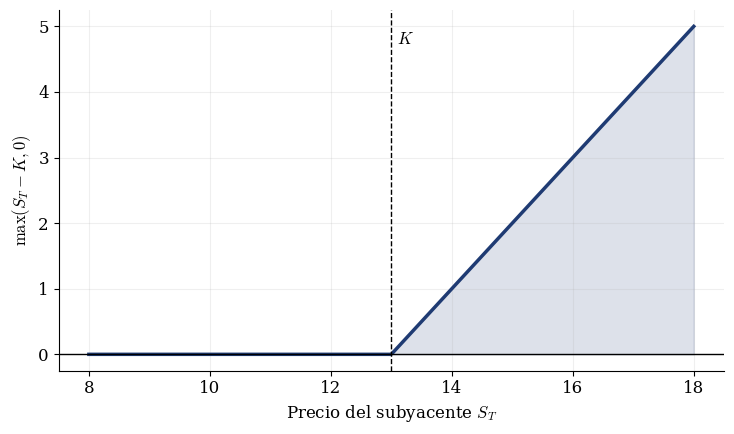

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
K = 13
S = np.linspace(8, 18, 500)
call = np.maximum(S - K, 0)

# Estilo
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Curva
ax.plot(S, call, color="#1f3b73", linewidth=2.5)

# Sombreado
ax.fill_between(S, call, where=(S >= K), alpha=0.15, color="#1f3b73")

# Líneas clave
ax.axvline(K, linestyle='--', color="black", linewidth=1)
ax.axhline(0, color="black", linewidth=1)

# Etiquetas
#ax.set_title("Función de pago de una opción Call europea", pad=10)
ax.set_xlabel(r"Precio del subyacente $S_T$")
ax.set_ylabel(r"$\max(S_T - K, 0)$")

# K visible (con fondo blanco)
ax.text(K + 0.1, ax.get_ylim()[1]*0.9, r"$K$",
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()

plt.show()

Opcion Put

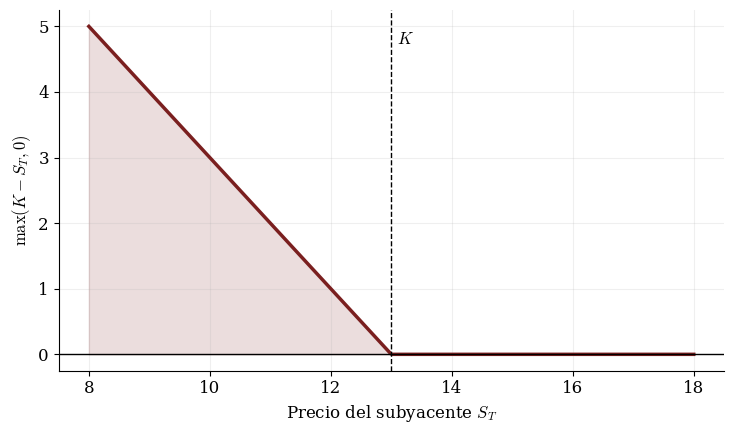

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
K = 13
S = np.linspace(8, 18, 500)
put = np.maximum(K - S, 0)

# Estilo
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Curva
ax.plot(S, put, color="#7a1f1f", linewidth=2.5)

# Sombreado
ax.fill_between(S, put, where=(S <= K), alpha=0.15, color="#7a1f1f")

# Líneas clave
ax.axvline(K, linestyle='--', color="black", linewidth=1)
ax.axhline(0, color="black", linewidth=1)

# Etiquetas
#ax.set_title("Función de pago de una opción Put europea", pad=10)
ax.set_xlabel(r"Precio del subyacente $S_T$")
ax.set_ylabel(r"$\max(K - S_T, 0)$")

# K visible (con fondo blanco)
ax.text(K + 0.1, ax.get_ylim()[1]*0.9, r"$K$",
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()

plt.show()

### Pariedad Call - Put

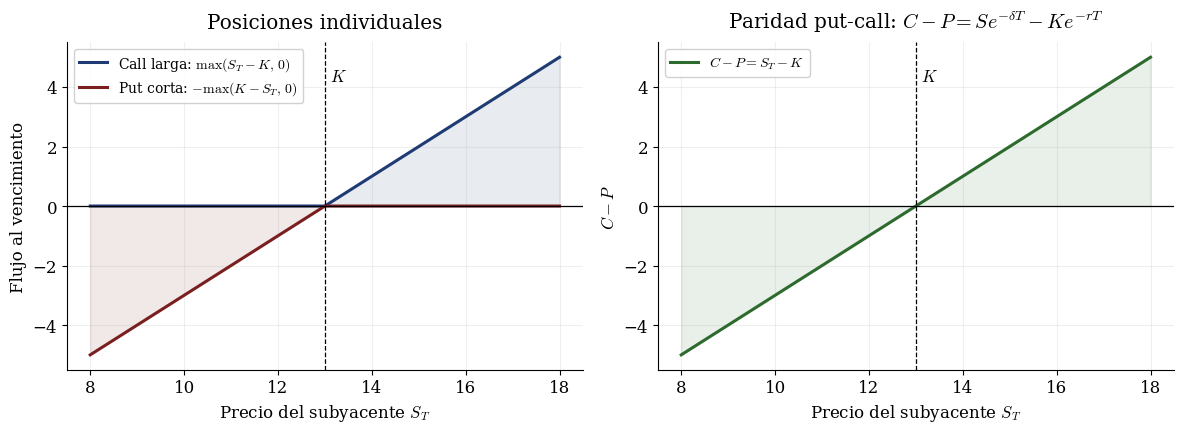

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
K = 13
r = 0.05
T = 1.0
S = np.linspace(8, 18, 500)

# Payoffs al vencimiento
call      =  np.maximum(S - K, 0)
put_corta = -np.maximum(K - S, 0)
forward   =  S - K                   # C - P = S_T - K  (al vencimiento, δ=0)

# Estilo
plt.rcParams.update({
    "font.family":      "serif",
    "mathtext.fontset": "cm",
    "font.size":        12
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

COLOR_CALL    = "#1f3b73"
COLOR_PUT     = "#7a1f1f"
COLOR_FORWARD = "#2d6a2d"

# ── Panel izquierdo: call larga y put corta ────────────────────
ax = axes[0]

ax.plot(S, call,      color=COLOR_CALL,    linewidth=2.2, label=r"Call larga: $\max(S_T - K,\,0)$")
ax.plot(S, put_corta, color=COLOR_PUT,     linewidth=2.2, label=r"Put corta: $-\max(K - S_T,\,0)$")

ax.fill_between(S, call,      0, where=(S >= K), alpha=0.10, color=COLOR_CALL)
ax.fill_between(S, put_corta, 0, where=(S <= K), alpha=0.10, color=COLOR_PUT)

ax.axvline(K, linestyle='--', color="black", linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.9)
ax.text(K + 0.1, 4.2, r"$K$",
        bbox=dict(facecolor='white', edgecolor='none', pad=1))

ax.set_title("Posiciones individuales", pad=10)
ax.set_xlabel(r"Precio del subyacente $S_T$")
ax.set_ylabel("Flujo al vencimiento")
ax.legend(fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

# ── Panel derecho: diferencia C - P = S_T - K ─────────────────
ax = axes[1]

ax.plot(S, forward, color=COLOR_FORWARD, linewidth=2.2,
        label=r"$C - P = S_T - K$")

ax.fill_between(S, forward, 0, where=(S >= K), alpha=0.10, color=COLOR_FORWARD)
ax.fill_between(S, forward, 0, where=(S <= K), alpha=0.10, color=COLOR_FORWARD)

ax.axvline(K, linestyle='--', color="black", linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.9)
ax.text(K + 0.1, 4.2, r"$K$",
        bbox=dict(facecolor='white', edgecolor='none', pad=1))

ax.set_title(r"Paridad put-call: $C - P = Se^{-\delta T} - Ke^{-rT}$", pad=10)
ax.set_xlabel(r"Precio del subyacente $S_T$")
ax.set_ylabel(r"$C - P$")
ax.legend(fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Arboles binomial

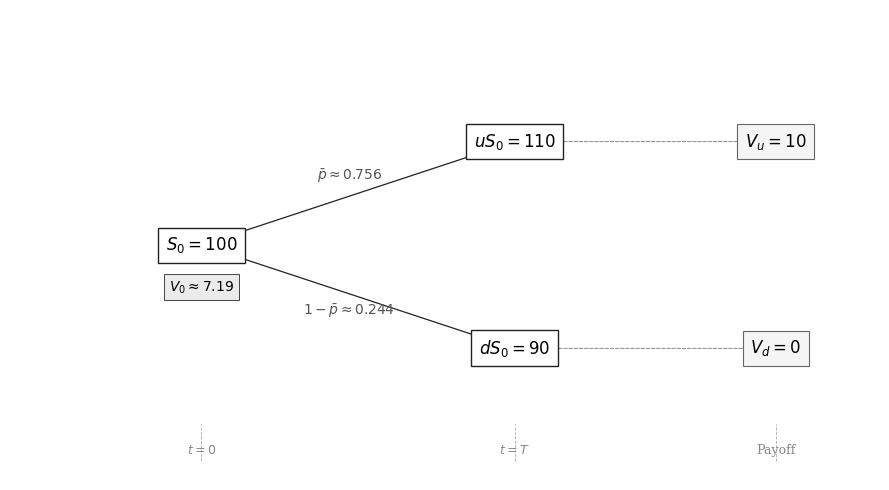

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# ── Coordenadas ────────────────────────────────────────────────
nodos = {'S':  (2.2, 5), 'Su': (5.8, 7.2), 'Sd': (5.8, 2.8)}
payof = {'Vu': (8.8, 7.2), 'Vd': (8.8, 2.8)}

box_kw   = dict(boxstyle='square,pad=0.45', fc='white',  ec='#222222', lw=1.0)
pay_kw   = dict(boxstyle='square,pad=0.45', fc='#f5f5f5', ec='#666666', lw=0.8)
val_kw   = dict(boxstyle='square,pad=0.35', fc='#ebebeb', ec='#444444', lw=0.7)
arr_kw   = dict(arrowstyle='->', color='#222222', lw=0.9,
                connectionstyle='arc3,rad=0.0')
dash_kw  = dict(arrowstyle='->', color='#888888', lw=0.7,
                linestyle='dashed', connectionstyle='arc3,rad=0.0')

# ── Flechas del activo ─────────────────────────────────────────
for dest in ('Su', 'Sd'):
    ax.annotate('', xy=nodos[dest], xytext=nodos['S'],
                arrowprops=arr_kw)

# ── Flechas hacia payoff ───────────────────────────────────────
for src, dst in (('Su', 'Vu'), ('Sd', 'Vd')):
    ax.annotate('', xy=payof[dst], xytext=nodos[src],
                arrowprops=dash_kw)

# ── Etiquetas de probabilidad ──────────────────────────────────
mid_u = ((nodos['S'][0] + nodos['Su'][0]) / 2,
         (nodos['S'][1] + nodos['Su'][1]) / 2)
mid_d = ((nodos['S'][0] + nodos['Sd'][0]) / 2,
         (nodos['S'][1] + nodos['Sd'][1]) / 2)

ax.text(mid_u[0] - 0.1, mid_u[1] + 0.28,
        r'$\bar{p} \approx 0.756$',
        fontsize=10, ha='center', color='#555555',
        fontfamily='serif')
ax.text(mid_d[0] - 0.1, mid_d[1] - 0.38,
        r'$1 - \bar{p} \approx 0.244$',
        fontsize=10, ha='center', color='#555555',
        fontfamily='serif')

# ── Nodos del activo ───────────────────────────────────────────
etiq = {
    'S':  r'$S_0 = 100$',
    'Su': r'$uS_0 = 110$',
    'Sd': r'$dS_0 = 90$',
}
for k, (x, y) in nodos.items():
    ax.annotate(etiq[k], xy=(x, y),
                fontsize=12, ha='center', va='center',
                fontfamily='serif', bbox=box_kw)

# ── Nodos de payoff ────────────────────────────────────────────
etiq_p = {'Vu': r'$V_u = 10$', 'Vd': r'$V_d = 0$'}
for k, (x, y) in payof.items():
    ax.annotate(etiq_p[k], xy=(x, y),
                fontsize=12, ha='center', va='center',
                fontfamily='serif', bbox=pay_kw)

# ── Valor inicial de la opción ─────────────────────────────────
x0, y0 = nodos['S']
ax.annotate(r'$V_0 \approx 7.19$', xy=(x0, y0 - 0.9),
            fontsize=10, ha='center', va='center',
            fontfamily='serif', bbox=val_kw)

# ── Líneas de tiempo ───────────────────────────────────────────
for xp, lbl in ((2.2, r'$t = 0$'), (5.8, r'$t = T$'),
                (8.8, 'Payoff')):
    ax.axvline(xp, ymin=0.04, ymax=0.12,
               color='#aaaaaa', lw=0.6, linestyle='--')
    ax.text(xp, 0.55, lbl, fontsize=9, ha='center',
            color='#888888', fontfamily='serif')

plt.tight_layout()

plt.show()

Listo.


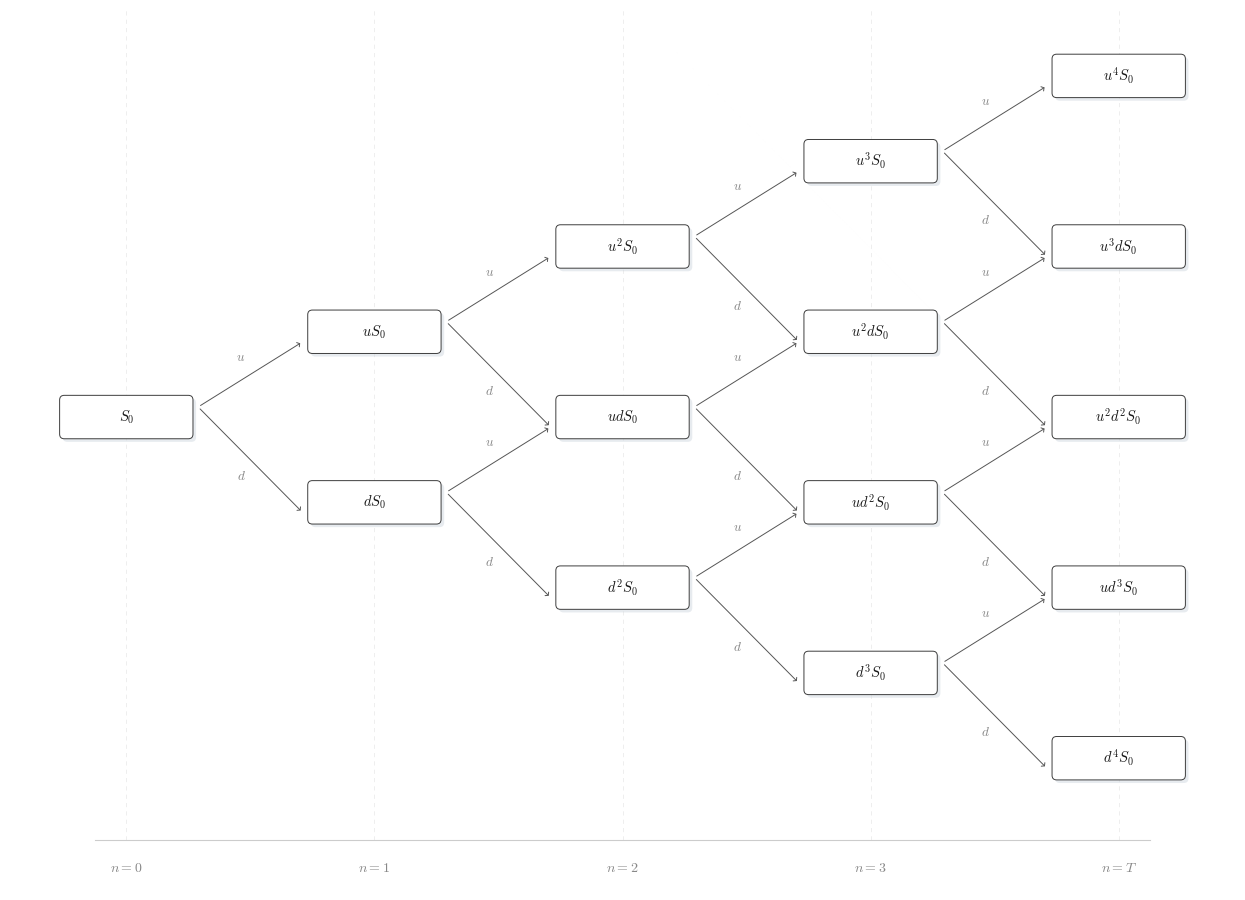

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'font.family':      'serif',
    'text.usetex':      False,
})

def plot_crr_tree(N=4, figsize=(16, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    C = {
        'box_edge' : '#3d3d3d',
        'box_fill' : '#ffffff',
        'box_shad' : '#d0d8e0',
        'arrow'    : '#555555',
        'label_ud' : '#888888',
        'text'     : '#1a1a1a',
        'axis'     : '#cccccc',
        'tick_lbl' : '#888888',
    }

    x_gap, y_gap = 3.2, 2.2
    bw, bh = 1.72, 0.56
    rx = 0.06

    def pos(n, k):
        return n * x_gap, (n / 2 - k) * y_gap

    # ── Flechas ────────────────────────────────────────────────
    for n in range(N):
        for k in range(n + 1):
            x0, y0 = pos(n, k)
            for dk, sym in [(0, 'u'), (1, 'd')]:
                x1, y1 = pos(n + 1, k + dk)
                dx, dy = x1 - x0, y1 - y0
                L = np.hypot(dx, dy)
                ux, uy = dx / L, dy / L
                sgn = 1 if dy >= 0 else -1
                xs = x0 + ux * (bw / 2 + 0.12)
                ys = y0 + sgn * uy * (bh / 2 + 0.12)
                xe = x1 - ux * (bw / 2 + 0.12)
                ye = y1 - sgn * uy * (bh / 2 + 0.12)

                ax.annotate('', xy=(xe, ye), xytext=(xs, ys),
                    arrowprops=dict(
                        arrowstyle='->, head_width=0.15, head_length=0.12',
                        color=C['arrow'], lw=0.7,
                        connectionstyle='arc3,rad=0.0'))

                mx, my = (xs + xe) / 2, (ys + ye) / 2
                off = 0.22 if dk == 0 else -0.22
                ax.text(mx - 0.12, my + off, f'${sym}$',
                    fontsize=9.5, color=C['label_ud'],
                    ha='center', va='center',
                    style='italic', fontfamily='serif')

    # ── Nodos ──────────────────────────────────────────────────
    for n in range(N + 1):
        for k in range(n + 1):
            x, y = pos(n, k)
            ups, dn = n - k, k

            if ups == 0 and dn == 0:
                lbl = r'$S_0$'
            elif dn == 0:
                e = f'^{{{ups}}}' if ups > 1 else ''
                lbl = rf'$u{e}S_0$'
            elif ups == 0:
                e = f'^{{{dn}}}' if dn > 1 else ''
                lbl = rf'$d{e}S_0$'
            else:
                eu = f'^{{{ups}}}' if ups > 1 else ''
                ed = f'^{{{dn}}}' if dn > 1 else ''
                lbl = rf'$u{eu}d{ed}S_0$'

            # Sombra
            shad = patches.FancyBboxPatch(
                (x - bw/2 + 0.04, y - bh/2 - 0.04),
                bw, bh,
                boxstyle=f'round,pad=0.0,rounding_size={rx}',
                linewidth=0,
                facecolor=C['box_shad'],
                zorder=2, alpha=0.5)
            ax.add_patch(shad)

            # Caja
            box = patches.FancyBboxPatch(
                (x - bw/2, y - bh/2),
                bw, bh,
                boxstyle=f'round,pad=0.0,rounding_size={rx}',
                linewidth=0.7,
                edgecolor=C['box_edge'],
                facecolor=C['box_fill'],
                zorder=3)
            ax.add_patch(box)

            ax.text(x, y, lbl,
                fontsize=10.5, ha='center', va='center',
                color=C['text'], fontfamily='serif', zorder=4)

    # ── Eje temporal ───────────────────────────────────────────
    yb = pos(N, N)[1] - 1.05
    yt = pos(N, 0)[1] + 0.85

    ax.plot([-0.4, N * x_gap + 0.4], [yb, yb],
            color=C['axis'], lw=0.8, zorder=1)

    for n in range(N + 1):
        xp = n * x_gap
        ax.plot([xp, xp], [yb + 0.0, yt],
                color='#ebebeb', lw=0.6,
                ls=(0, (5, 5)), zorder=0)
        lbl_n = rf'$n={n}$' if n < N else r'$n=T$'
        ax.text(xp, yb - 0.28, lbl_n,
                fontsize=10, ha='center', va='top',
                color=C['tick_lbl'], fontfamily='serif')

    # ── Límites ────────────────────────────────────────────────
    mx = 1.5
    ax.set_xlim(-mx, N * x_gap + mx)
    ax.set_ylim(yb - 0.65, yt)
    ax.set_aspect('equal')
    ax.axis('off')

    plt.tight_layout(pad=0.6)
    plt.savefig('crr_final.pdf',
                bbox_inches='tight', dpi=300, facecolor='white')
    plt.savefig('crr_final.png',
                bbox_inches='tight', dpi=300, facecolor='white')
    print("Listo.")

plot_crr_tree(N=4)

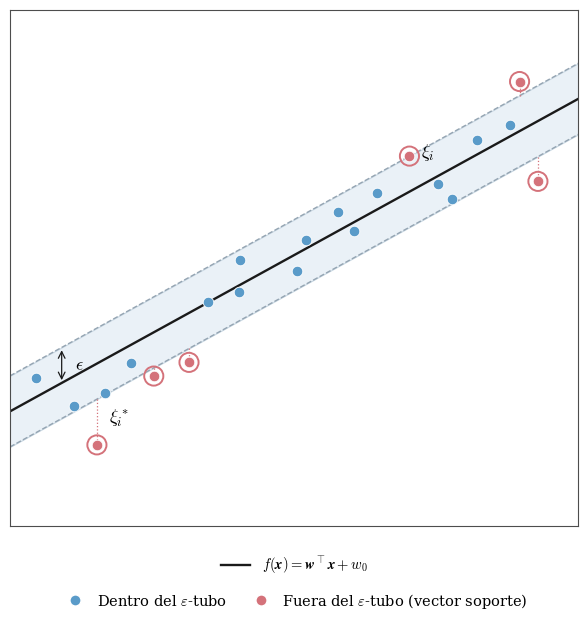

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Estilo formal / académico (consistente con las figuras 3D del capítulo)
# ------------------------------------------------------------------
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.linewidth'] = 0.8

# ------------------------------------------------------------------
# Datos sintéticos alrededor de una recta de regresión
# (dispersión no homogénea: la nube no sigue una covarianza paralela)
# ------------------------------------------------------------------
rng = np.random.default_rng(11)

n = 22
x = np.linspace(-4, 4, n) + rng.normal(0, 0.15, n)
w1, w0 = 0.55, 0.2
y_central = w1 * x + w0

ruido = rng.normal(0, 0.35 + 0.10 * np.abs(x), n)
y = y_central + ruido

epsilon = 0.55

x_line = np.linspace(-4.5, 4.5, 100)
y_line = w1 * x_line + w0
y_sup = y_line + epsilon
y_inf = y_line - epsilon

y_pred = w1 * x + w0
residuo = y - y_pred
dentro = np.abs(residuo) <= epsilon
fuera_arriba = residuo > epsilon
fuera_abajo = residuo < -epsilon
fuera = fuera_arriba | fuera_abajo

# ------------------------------------------------------------------
# Paleta consistente con las gráficas 3D del capítulo:
# azules/grises para lo "correcto" o estructural, rojo/salmón
# reservado para lo que rompe la regla (vectores soporte de error).
# ------------------------------------------------------------------
color_dentro = '#5A9BC9'     # azul acero, igual familia que color_h1_leg en 3D
color_fuera = '#D4727A'      # rosa/salmón, igual familia que color_h3_leg en 3D
color_central = '#1a1a1a'
color_borde = '#94A4B2'      # gris azulado, igual familia que color_h2_surf en 3D
color_tubo = '#EAF1F7'       # relleno translúcido del tubo
color_tubo_edge = '#C9D8E3'
color_holgura = '#D4727A'

# ------------------------------------------------------------------
# Figura
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6.4))

# Tubo con relleno translúcido y borde sutil (misma lógica de "capas"
# translúcidas que en las superficies de las gráficas 3D)
ax.fill_between(x_line, y_inf, y_sup, color=color_tubo,
                edgecolor=color_tubo_edge, linewidth=0.8, zorder=0)

ax.plot(x_line, y_line, color=color_central, linewidth=1.7, zorder=2,
        label=r'$f(\boldsymbol{x}) = \boldsymbol{w}^\top \boldsymbol{x} + w_0$')
ax.plot(x_line, y_sup, color=color_borde, linewidth=1.0, linestyle='--', zorder=2)
ax.plot(x_line, y_inf, color=color_borde, linewidth=1.0, linestyle='--', zorder=2)

# Puntos dentro del tubo
ax.scatter(x[dentro], y[dentro], marker='o', s=58,
           facecolor=color_dentro, edgecolor='white', linewidth=0.6,
           zorder=3)

# Puntos fuera del tubo (vectores soporte): relleno + contorno destacado,
# igual que el estilo de marcador con markeredgecolor='white' en las 3D
ax.scatter(x[fuera], y[fuera], marker='o', s=58,
           facecolor=color_fuera, edgecolor='white', linewidth=0.6,
           zorder=4)
ax.scatter(x[fuera], y[fuera], marker='o', s=190,
           facecolor='none', edgecolor=color_fuera, linewidth=1.4, zorder=4)

# Líneas de holgura (xi, xi*)
for xi_, yi_ in zip(x[fuera_arriba], y[fuera_arriba]):
    y_borde = w1 * xi_ + w0 + epsilon
    ax.plot([xi_, xi_], [y_borde, yi_], color=color_holgura,
            linewidth=0.9, linestyle=':', zorder=2)

for xi_, yi_ in zip(x[fuera_abajo], y[fuera_abajo]):
    y_borde = w1 * xi_ + w0 - epsilon
    ax.plot([xi_, xi_], [y_borde, yi_], color=color_holgura,
            linewidth=0.9, linestyle=':', zorder=2)

# Anotación de epsilon
x_ref = -3.6
ax.annotate('', xy=(x_ref, w1 * x_ref + w0 + epsilon),
            xytext=(x_ref, w1 * x_ref + w0),
            arrowprops=dict(arrowstyle='<->', color=color_central, linewidth=0.9))
ax.text(x_ref + 0.2, w1 * x_ref + w0 + epsilon / 2, r'$\epsilon$',
        fontsize=13, va='center')

# Anotaciones de xi, xi*
if fuera_arriba.any():
    idx = np.where(fuera_arriba)[0][0]
    xi_, yi_ = x[idx], y[idx]
    y_borde = w1 * xi_ + w0 + epsilon
    ax.text(xi_ + 0.18, (yi_ + y_borde) / 2, r'$\xi_i$', fontsize=13)

if fuera_abajo.any():
    idx = np.where(fuera_abajo)[0][0]
    xi_, yi_ = x[idx], y[idx]
    y_borde = w1 * xi_ + w0 - epsilon
    ax.text(xi_ + 0.18, (yi_ + y_borde) / 2, r'$\xi_i^*$', fontsize=13)

# Caja delgada en vez de ejes sueltos (consistente con el marco de las 3D)
ax.set_xlim(-4.4, 4.4)
ax.set_ylim(-4.0, 4.0)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#4d4d4d')
    spine.set_linewidth(0.8)

# ------------------------------------------------------------------
# Leyenda con Line2D/handles explícitos, igual estilo que las 3D:
# nivel 1 = la función central; nivel 2 = las dos categorías de puntos,
# incluyendo un handle textual para "vector soporte".
# ------------------------------------------------------------------
handle_funcion = Line2D([0], [0], color=color_central, linewidth=1.7,
                         label=r'$f(\boldsymbol{x}) = \boldsymbol{w}^\top \boldsymbol{x} + w_0$')
handle_dentro = Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dentro,
                        markersize=8, markeredgecolor='white',
                        label=r'Dentro del $\varepsilon$-tubo')
handle_fuera = Line2D([0], [0], marker='o', color='w', markerfacecolor=color_fuera,
                       markersize=8, markeredgecolor='white',
                       label=r'Fuera del $\varepsilon$-tubo (vector soporte)')

leg1 = ax.legend(handles=[handle_funcion],
                  loc='upper center', bbox_to_anchor=(0.5, -0.03),
                  frameon=False, fontsize=10.5)
ax.add_artist(leg1)

ax.legend(handles=[handle_dentro, handle_fuera],
          loc='upper center', bbox_to_anchor=(0.5, -0.10),
          ncol=2, frameon=False, fontsize=10.5,
          handletextpad=0.5, columnspacing=1.3)

plt.tight_layout()
plt.savefig('svr_epsilon_tube.png', dpi=200, bbox_inches='tight')
plt.show()

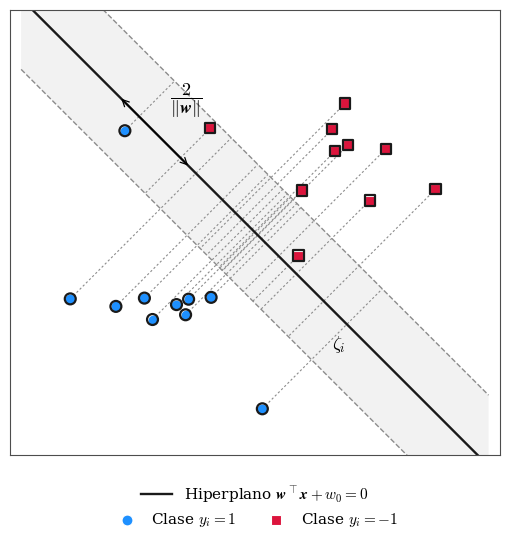

In [39]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Estilo formal / académico
# ------------------------------------------------------------------
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.linewidth'] = 0.9

# ------------------------------------------------------------------
# Datos sintéticos con traslape (no separables perfectamente)
# ------------------------------------------------------------------
rng = np.random.default_rng(3)
n = 10
clase1 = rng.normal(loc=[-1.6, -1.0], scale=0.85, size=(n, 2))
clase2 = rng.normal(loc=[1.6, 1.0], scale=0.85, size=(n, 2))

w = np.array([1.0, 1.0])
w0 = 0.0
margen = 0.9

x_vals = np.linspace(-4.2, 4.2, 100)

def linea(x, offset):
    return (offset - w0 - w[0] * x) / w[1]

y_hiperplano = linea(x_vals, 0)
y_margen_sup = linea(x_vals, margen * np.linalg.norm(w))
y_margen_inf = linea(x_vals, -margen * np.linalg.norm(w))

def valor_signado(punto):
    return (w @ punto + w0) / np.linalg.norm(w)

val1 = np.array([valor_signado(p) for p in clase1])
val2 = np.array([valor_signado(p) for p in clase2])

incumple1 = val1 < margen
incumple2 = val2 > -margen
sv1 = incumple1
sv2 = incumple2

# ------------------------------------------------------------------
# Paleta: rojo intenso y azul claro
# ------------------------------------------------------------------
color_clase1 = '#1E90FF'    # Azul claro (DodgerBlue)
color_clase2 = '#DC143C'    # Rojo intenso (Crimson)
color_linea = '#1a1a1a'
color_margen = '#8c8c8c'
color_sv = '#1a1a1a'
color_holgura = '#8c8c8c'

fig, ax = plt.subplots(figsize=(6.8, 5.6))

# Región del margen: relleno plano, sin trama
ax.fill_between(x_vals, y_margen_inf, y_margen_sup,
                facecolor='#f2f2f2', edgecolor='none', zorder=0)

# Líneas de holgura (discretas, detrás de los puntos)
for p, v in zip(clase1[incumple1], val1[incumple1]):
    proyeccion = p - (v - margen) * w / np.linalg.norm(w)
    ax.plot([p[0], proyeccion[0]], [p[1], proyeccion[1]],
            color=color_holgura, linewidth=0.8, linestyle=(0, (2, 2)), zorder=1)

for p, v in zip(clase2[incumple2], val2[incumple2]):
    proyeccion = p - (v + margen) * w / np.linalg.norm(w)
    ax.plot([p[0], proyeccion[0]], [p[1], proyeccion[1]],
            color=color_holgura, linewidth=0.8, linestyle=(0, (2, 2)), zorder=1)

# Hiperplano y márgenes
ax.plot(x_vals, y_hiperplano, color=color_linea, linewidth=1.7, zorder=2,
        label=r'Hiperplano $\boldsymbol{w}^\top \boldsymbol{x} + w_0 = 0$')
ax.plot(x_vals, y_margen_sup, color=color_margen, linewidth=1.0, linestyle='--', zorder=2)
ax.plot(x_vals, y_margen_inf, color=color_margen, linewidth=1.0, linestyle='--', zorder=2)

# Puntos de cada clase: marcador distinto, no solo color
ax.scatter(clase1[:, 0], clase1[:, 1], marker='o', s=62,
           facecolor=color_clase1, edgecolor='white', linewidth=0.8,
           label=r'Clase $y_i = 1$', zorder=3)
ax.scatter(clase2[:, 0], clase2[:, 1], marker='s', s=54,
           facecolor=color_clase2, edgecolor='white', linewidth=0.8,
           label=r'Clase $y_i = -1$', zorder=3)

# Vectores soporte: un solo anillo, más grueso (sin doble anillo)
ax.scatter(clase1[sv1, 0], clase1[sv1, 1], marker='o', s=62,
           facecolor='none', edgecolor=color_sv, linewidth=1.6, zorder=4)
ax.scatter(clase2[sv2, 0], clase2[sv2, 1], marker='s', s=54,
           facecolor='none', edgecolor=color_sv, linewidth=1.6, zorder=4)

# Anotación de una holgura representativa
if incumple1.any():
    idx = np.where(incumple1)[0][0]
    p = clase1[idx]
    v = val1[idx]
    proyeccion = p - (v - margen) * w / np.linalg.norm(w)
    punto_medio = (p + proyeccion) / 2
    ax.text(punto_medio[0] + 0.18, punto_medio[1], r'$\zeta_i$', fontsize=13)

# ------------------------------------------------------------------
# Anotación perpendicular del ancho del margen
# La flecha doble debe estar en la ZONA del margen, no sobre el hiperplano.
# La colocamos en la zona IZQUIERDA pero más centrada para no cortarse.
# ------------------------------------------------------------------
w_hat = w / np.linalg.norm(w)
n_hat = np.array([-w_hat[1], w_hat[0]])  # normal unitario a w, sobre la banda

# Elegimos x0_ref = -1.8 (zona izquierda, más centrada, evita borde)
x0_ref = -1.8
p_centro = np.array([x0_ref, linea(x0_ref, 0)])
p_sup = p_centro + margen * n_hat
p_inf = p_centro - margen * n_hat

ax.annotate('', xy=(p_sup[0], p_sup[1]), xytext=(p_inf[0], p_inf[1]),
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=0.9),
            zorder=5)

punto_medio_margen = (p_sup + p_inf) / 2
# Desplazamos la etiqueta en la dirección PARALELA al hiperplano (w_hat)
# para que quede hacia la derecha, dentro del canvas, lejos del borde
offset = 0.8 * w_hat
ax.text(punto_medio_margen[0] + offset[0], punto_medio_margen[1] + offset[1],
        r'$\dfrac{2}{\Vert\boldsymbol{w}\Vert}$', fontsize=13,
        ha='center', va='center', zorder=5)

# Caja delgada en vez de ejes sueltos
ax.set_xlim(-4.4, 4.4)
ax.set_ylim(-4.0, 4.0)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#4d4d4d')
    spine.set_linewidth(0.8)

# ------------------------------------------------------------------
# Leyenda en dos niveles
# ------------------------------------------------------------------
handles, labels = ax.get_legend_handles_labels()
handle_hiperplano = [h for h, l in zip(handles, labels) if 'Hiperplano' in l][0]
handles_clases = [h for h, l in zip(handles, labels) if 'Clase' in l]
labels_clases = [l for l in labels if 'Clase' in l]

leg1 = ax.legend(handles=[handle_hiperplano],
                  loc='upper center', bbox_to_anchor=(0.5, -0.035),
                  frameon=False, fontsize=11)
ax.add_artist(leg1)

ax.legend(handles=handles_clases, labels=labels_clases,
          loc='upper center', bbox_to_anchor=(0.5, -0.095),
          ncol=2, frameon=False, fontsize=11,
          handletextpad=0.6, columnspacing=1.6)

plt.tight_layout()

plt.show()


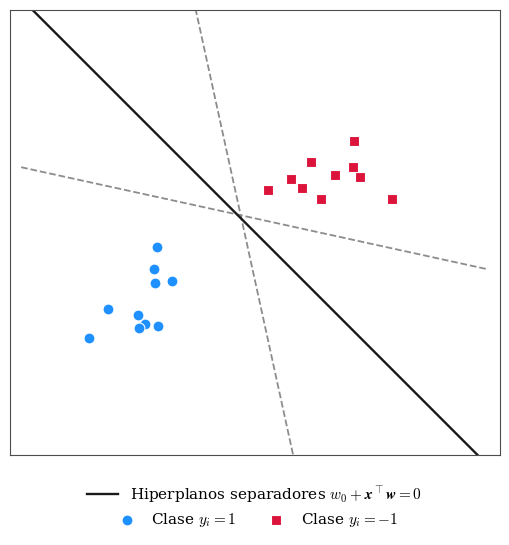

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Estilo formal / académico (mismas convenciones que la figura de margen)
# ------------------------------------------------------------------
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.linewidth'] = 0.9

# ------------------------------------------------------------------
# Datos sintéticos, perfectamente separables (sin traslape)
# ------------------------------------------------------------------
rng = np.random.default_rng(7)
n = 10
clase1 = rng.normal(loc=[-1.8, -1.1], scale=0.62, size=(n, 2))
clase2 = rng.normal(loc=[1.8, 1.1], scale=0.62, size=(n, 2))

x_vals = np.linspace(-4.2, 4.2, 100)

# ------------------------------------------------------------------
# Tres hiperplanos distintos, todos separan correctamente los datos
# Cada uno definido por (w0, w1, w2): w0 + w1*x1 + w2*x2 = 0
# ------------------------------------------------------------------
hiperplanos = [
    {'w0': 0.0,  'w': np.array([1.0, 1.0]),   'estilo': '-',  'ancho': 1.7, 'etiqueta': r'$H_1$'},
    {'w0': 0.3,  'w': np.array([1.6, 0.35]),  'estilo': '-',  'ancho': 1.3, 'etiqueta': r'$H_2$'},
    {'w0': -0.4, 'w': np.array([0.35, 1.6]),  'estilo': '-',  'ancho': 1.3, 'etiqueta': r'$H_3$'},
]

# ------------------------------------------------------------------
# Paleta (idéntica a la figura de margen)
# ------------------------------------------------------------------
color_clase1 = '#1E90FF'    # Azul claro (DodgerBlue)
color_clase2 = '#DC143C'    # Rojo intenso (Crimson)
color_h1 = '#1a1a1a'        # Hiperplano principal, en negro/gris oscuro
color_h_otros = '#8c8c8c'   # Hiperplanos alternativos, en gris

fig, ax = plt.subplots(figsize=(6.8, 5.6))

def linea(x, w0, w):
    return -(w0 + w[0] * x) / w[1]

# Hiperplanos alternativos primero (detrás), luego el "principal"
for h in hiperplanos[1:]:
    y_vals = linea(x_vals, h['w0'], h['w'])
    ax.plot(x_vals, y_vals, color=color_h_otros, linewidth=h['ancho'],
            linestyle='--', zorder=1)

h1 = hiperplanos[0]
y_vals_h1 = linea(x_vals, h1['w0'], h1['w'])
ax.plot(x_vals, y_vals_h1, color=color_h1, linewidth=h1['ancho'], zorder=2,
        label=r'Hiperplanos separadores $w_0 + \boldsymbol{x}^\top\boldsymbol{w} = 0$')

# Puntos de cada clase: marcador distinto, no solo color
ax.scatter(clase1[:, 0], clase1[:, 1], marker='o', s=62,
           facecolor=color_clase1, edgecolor='white', linewidth=0.8,
           label=r'Clase $y_i = 1$', zorder=3)
ax.scatter(clase2[:, 0], clase2[:, 1], marker='s', s=54,
           facecolor=color_clase2, edgecolor='white', linewidth=0.8,
           label=r'Clase $y_i = -1$', zorder=3)

# Caja delgada en vez de ejes sueltos
ax.set_xlim(-4.4, 4.4)
ax.set_ylim(-4.0, 4.0)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#4d4d4d')
    spine.set_linewidth(0.8)

# ------------------------------------------------------------------
# Leyenda en dos niveles (misma estructura que la figura de margen)
# ------------------------------------------------------------------
handles, labels = ax.get_legend_handles_labels()
handle_hiperplano = [h for h, l in zip(handles, labels) if 'Hiperplanos' in l][0]
handles_clases = [h for h, l in zip(handles, labels) if 'Clase' in l]
labels_clases = [l for l in labels if 'Clase' in l]

leg1 = ax.legend(handles=[handle_hiperplano],
                  loc='upper center', bbox_to_anchor=(0.5, -0.035),
                  frameon=False, fontsize=11)
ax.add_artist(leg1)

ax.legend(handles=handles_clases, labels=labels_clases,
          loc='upper center', bbox_to_anchor=(0.5, -0.095),
          ncol=2, frameon=False, fontsize=11,
          handletextpad=0.6, columnspacing=1.6)

plt.tight_layout()

plt.show()

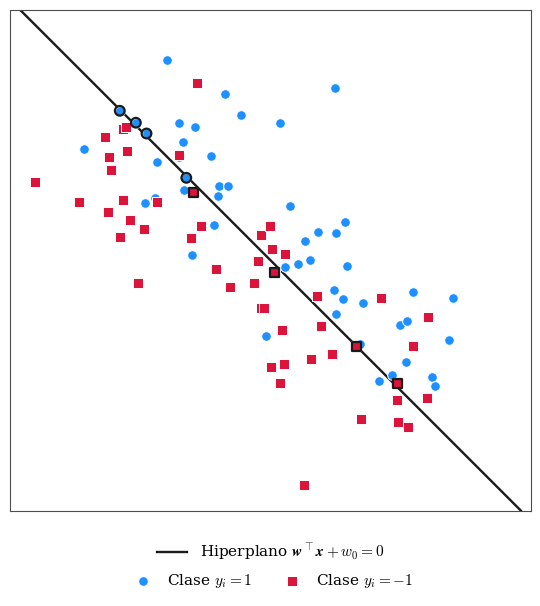

In [50]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Estilo formal / académico
# ------------------------------------------------------------------
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.linewidth'] = 0.9

# ------------------------------------------------------------------
# Hiperplano de referencia: w0 + w^T x = 0, pasa por el origen
# ------------------------------------------------------------------
w = np.array([1.0, 1.0])
w0 = 0.0
w_norm = np.linalg.norm(w)
w_hat = w / w_norm                       # dirección normal al hiperplano
t_hat = np.array([-w_hat[1], w_hat[0]])  # dirección A LO LARGO del hiperplano

margen = 0.9

def punto(s, d):
    """s: posición a lo largo del hiperplano, d: distancia con signo al hiperplano."""
    return s * t_hat + d * w_hat

# ------------------------------------------------------------------
# Datos con MUCHOS puntos cerca del hiperplano
# ------------------------------------------------------------------
rng = np.random.default_rng(42)
n = 50  # más puntos por clase

# Clase 1 (azul, y=1): mayoría cerca del hiperplano
s_vals_1 = rng.uniform(-4.5, 4.5, n)
# Muchos puntos cerca del hiperplano (distribución más concentrada)
d_vals_1 = np.concatenate([
    rng.uniform(-0.3, 0.3, 15),      # 15 puntos MUY cerca del hiperplano
    rng.uniform(0.3, margen, 15),    # 15 puntos dentro del margen
    rng.uniform(margen, margen + 1.0, 12),  # 12 puntos justo fuera del margen
    rng.uniform(-1.5, -0.3, 5),       # 5 puntos en zona negativa (mal clasificados)
    rng.uniform(margen + 1.0, margen + 2.5, 3),  # 3 puntos lejanos
])
# Barajar
rng.shuffle(d_vals_1)
clase1 = np.array([punto(s, d) for s, d in zip(s_vals_1, d_vals_1)])

# Clase 2 (rojo, y=-1): mayoría cerca del hiperplano
s_vals_2 = rng.uniform(-4.5, 4.5, n)
d_vals_2 = np.concatenate([
    rng.uniform(-0.3, 0.3, 15),      # 15 puntos MUY cerca del hiperplano
    rng.uniform(-margen, -0.3, 15),   # 15 puntos dentro del margen (lado negativo)
    rng.uniform(-margen - 1.0, -margen, 12),  # 12 puntos justo fuera del margen
    rng.uniform(0.3, 1.5, 5),        # 5 puntos en zona positiva (mal clasificados)
    rng.uniform(-margen - 2.5, -margen - 1.0, 3),  # 3 puntos lejanos
])
rng.shuffle(d_vals_2)
clase2 = np.array([punto(s, d) for s, d in zip(s_vals_2, d_vals_2)])

# Vectores soporte: los más cercanos al hiperplano (en ambos lados)
dist1 = np.abs(np.dot(clase1, w) + w0) / w_norm
dist2 = np.abs(np.dot(clase2, w) + w0) / w_norm

idx_sv1 = np.argsort(dist1)[:4]
idx_sv2 = np.argsort(dist2)[:4]

sv1_mask = np.zeros(n, dtype=bool)
sv1_mask[idx_sv1] = True
sv2_mask = np.zeros(n, dtype=bool)
sv2_mask[idx_sv2] = True

x_vals = np.linspace(-5.0, 5.0, 100)

def linea(x, offset):
    return (offset - w0 - w[0] * x) / w[1]

y_hiperplano = linea(x_vals, 0)

# ------------------------------------------------------------------
# Paleta
# ------------------------------------------------------------------
color_clase1 = '#1E90FF'    # Azul claro (DodgerBlue)
color_clase2 = '#DC143C'    # Rojo intenso (Crimson)
color_linea = '#1a1a1a'
color_sv = '#1a1a1a'

fig, ax = plt.subplots(figsize=(7.2, 6.2))

# SÓLO el hiperplano de separación
ax.plot(x_vals, y_hiperplano, color=color_linea, linewidth=1.7, zorder=2,
        label=r'Hiperplano $\boldsymbol{w}^\top \boldsymbol{x} + w_0 = 0$')

# Puntos de cada clase (tamaño ligeramente menor para que no se amontonen)
ax.scatter(clase1[:, 0], clase1[:, 1], marker='o', s=48,
           facecolor=color_clase1, edgecolor='white', linewidth=0.7,
           label=r'Clase $y_i = 1$', zorder=3)
ax.scatter(clase2[:, 0], clase2[:, 1], marker='s', s=42,
           facecolor=color_clase2, edgecolor='white', linewidth=0.7,
           label=r'Clase $y_i = -1$', zorder=3)

# Vectores soporte: anillo grueso
ax.scatter(clase1[sv1_mask, 0], clase1[sv1_mask, 1], marker='o', s=48,
           facecolor='none', edgecolor=color_sv, linewidth=1.6, zorder=4)
ax.scatter(clase2[sv2_mask, 0], clase2[sv2_mask, 1], marker='s', s=42,
           facecolor='none', edgecolor=color_sv, linewidth=1.6, zorder=4)

# Caja delgada
ax.set_xlim(-5.2, 5.2)
ax.set_ylim(-5.0, 5.0)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#4d4d4d')
    spine.set_linewidth(0.8)

# Leyenda en dos niveles
handles, labels = ax.get_legend_handles_labels()
handle_hiperplano = [h for h, l in zip(handles, labels) if 'Hiperplano' in l][0]
handles_clases = [h for h, l in zip(handles, labels) if 'Clase' in l]
labels_clases = [l for l in labels if 'Clase' in l]

leg1 = ax.legend(handles=[handle_hiperplano],
                  loc='upper center', bbox_to_anchor=(0.5, -0.035),
                  frameon=False, fontsize=11)
ax.add_artist(leg1)

ax.legend(handles=handles_clases, labels=labels_clases,
          loc='upper center', bbox_to_anchor=(0.5, -0.095),
          ncol=2, frameon=False, fontsize=11,
          handletextpad=0.6, columnspacing=1.6)

plt.tight_layout()
plt.show()



Error H3: 0.43333333333333335


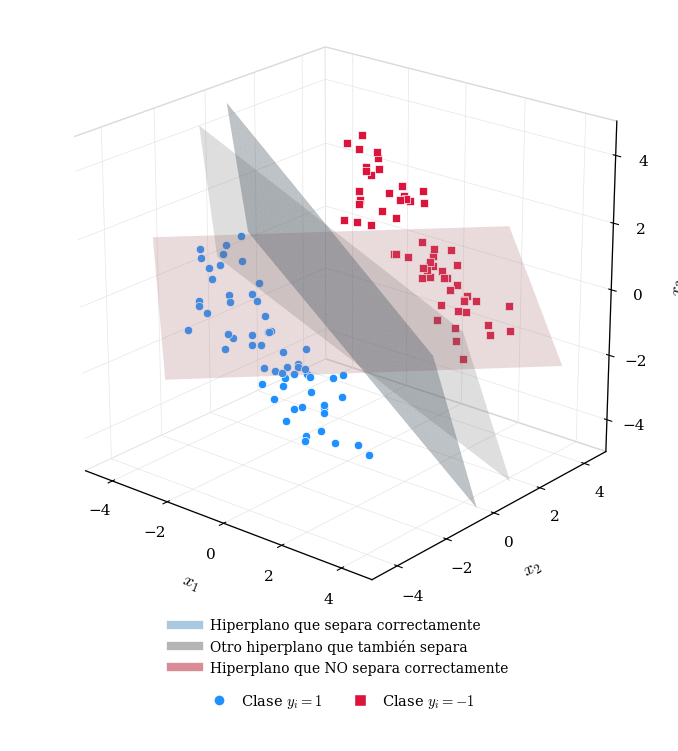

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 11
mpl.rcParams['mathtext.fontset'] = 'cm'

rng = np.random.default_rng(7)

# Hiperplano "verdadero" (dirección de separación real de los datos)
w_true = np.array([1., 1., 1.])
w_true = w_true / np.linalg.norm(w_true)

u = np.array([1., -1., 0.])
u = u / np.linalg.norm(u)
v = np.cross(w_true, u)
v = v / np.linalg.norm(v)

def punto(s, t, d):
    return s * u + t * v + d * w_true

n = 60
s1 = rng.uniform(-3.2, 3.2, n)
t1 = rng.uniform(-3.2, 3.2, n)
d1 = rng.normal(-2.4, 0.5, n)
clase1 = np.array([punto(s, t, d) for s, t, d in zip(s1, t1, d1)])

s2 = rng.uniform(-3.2, 3.2, n)
t2 = rng.uniform(-3.2, 3.2, n)
d2 = rng.normal(2.4, 0.5, n)
clase2 = np.array([punto(s, t, d) for s, t, d in zip(s2, t2, d2)])

color_clase1 = '#1E90FF'
color_clase2 = '#DC143C'

# --- Tres hiperplanos candidatos ---
s_grid = np.linspace(-5, 5, 40)
t_grid = np.linspace(-5, 5, 40)
S, T = np.meshgrid(s_grid, t_grid)

def superficie(w_n, w0, s_range=5):
    sg = np.linspace(-s_range, s_range, 40)
    tg = np.linspace(-s_range, s_range, 40)
    Sg, Tg = np.meshgrid(sg, tg)
    u2 = np.array([1., -1., 0.]); u2 = u2/np.linalg.norm(u2)
    v2 = np.cross(w_n, u2); v2 = v2/np.linalg.norm(v2)
    Q = Sg[:,:,None]*u2 + Tg[:,:,None]*v2 - w0*w_n
    return Q[:,:,0], Q[:,:,1], Q[:,:,2]

# H1: separador correcto (el "bueno", alineado con w_true)
w1, w0_1 = w_true, 0.0

# H2: otro separador correcto, con una ligera inclinación distinta
w2 = np.array([1.0, 1.0, 1.55]); w2 = w2/np.linalg.norm(w2)
w0_2 = -(np.min(clase2 @ w2) + np.max(clase1 @ w2)) / 2

# H3: hiperplano que NO separa bien (orientación casi ortogonal a w_true)
w3 = np.array([1.0, -1.0, 0.25]); w3 = w3/np.linalg.norm(w3)
w0_3 = 0.0
err3 = np.mean(clase1 @ w3 + w0_3 > 0) * 0.5 + np.mean(clase2 @ w3 + w0_3 < 0) * 0.5
print("Error H3:", err3)

XX1, YY1, ZZ1 = superficie(w1, w0_1)
XX2, YY2, ZZ2 = superficie(w2, w0_2)
XX3, YY3, ZZ3 = superficie(w3, w0_3)

fig = plt.figure(figsize=(8.5, 9.5))
gs = GridSpec(2, 1, height_ratios=[10, 1.3], hspace=0.18)
ax = fig.add_subplot(gs[0], projection='3d')

# H2 y H3 primero (fondo), H1 al final (protagonista)
ax.plot_surface(XX3, YY3, ZZ3, color="#E8A0A8", alpha=0.28, edgecolor="none", zorder=1)
ax.plot_surface(XX2, YY2, ZZ2, color="#cfcfcf", alpha=0.22, edgecolor="none", zorder=1)
ax.plot_surface(XX1, YY1, ZZ1, color="#A9C9E0", alpha=0.38, edgecolor="none", zorder=2)

ax.scatter(clase1[:,0], clase1[:,1], clase1[:,2], marker='o', s=36,
           color=color_clase1, edgecolors="white", linewidth=0.5,
           depthshade=False, zorder=3)
ax.scatter(clase2[:,0], clase2[:,1], clase2[:,2], marker='s', s=34,
           color=color_clase2, edgecolors="white", linewidth=0.5,
           depthshade=False, zorder=3)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor('white')
    axis.pane.set_edgecolor('#d9d9d9')
    axis.pane.set_alpha(1.0)
    axis._axinfo['grid'].update(color='#e6e6e6', linewidth=0.5)

ax.set_xlabel(r'$x_1$', fontsize=13, labelpad=8)
ax.set_ylabel(r'$x_2$', fontsize=13, labelpad=8)
ax.set_zlabel(r'$x_3$', fontsize=13, labelpad=8)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_zlim(-5, 5)
ax.view_init(elev=22, azim=-50)
ax.set_box_aspect((1,1,0.95), zoom=1.05)

ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off')

handle_h1 = Line2D([0],[0], color="#A9C9E0", linewidth=6, label='Hiperplano que separa correctamente')
handle_h2 = Line2D([0],[0], color="#b5b5b5", linewidth=6, label='Otro hiperplano que también separa')
handle_h3 = Line2D([0],[0], color="#d98c95", linewidth=6, label='Hiperplano que NO separa correctamente')
handle_clase1 = Line2D([0],[0], marker='o', color='w', markerfacecolor=color_clase1,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i=1$')
handle_clase2 = Line2D([0],[0], marker='s', color='w', markerfacecolor=color_clase2,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i=-1$')

leg1 = ax_leg.legend(handles=[handle_h1, handle_h2, handle_h3],
                      loc='upper center', bbox_to_anchor=(0.5, 1.75),
                      frameon=False, fontsize=10, ncol=1)
ax_leg.add_artist(leg1)
ax_leg.legend(handles=[handle_clase1, handle_clase2],
              loc='upper center', bbox_to_anchor=(0.5, .8),
              ncol=2, frameon=False, fontsize=10.5,
              handletextpad=0.5, columnspacing=1.6)
plt.show()

Error H3: 0.5416666666666667


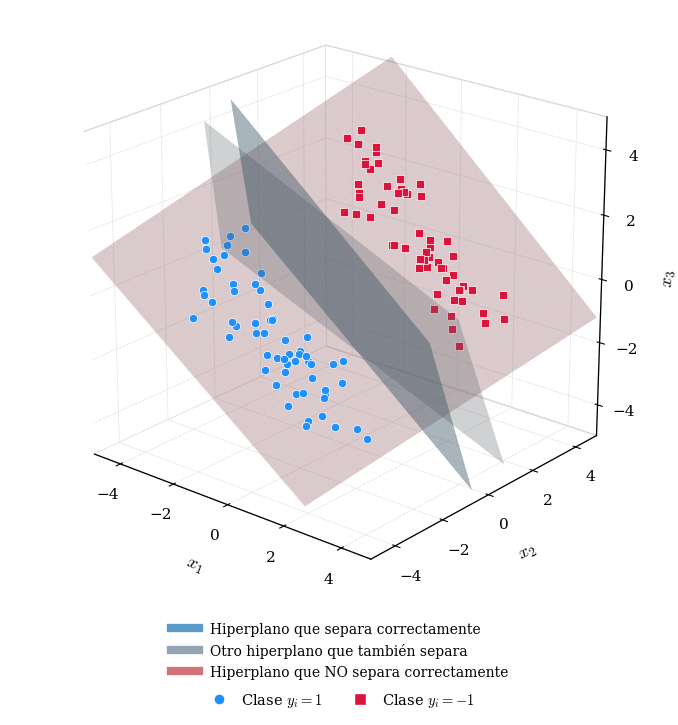

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 11
mpl.rcParams['mathtext.fontset'] = 'cm'

rng = np.random.default_rng(7)

# Hiperplano "verdadero"
w_true = np.array([1., 1., 1.])
w_true = w_true / np.linalg.norm(w_true)

u = np.array([1., -1., 0.])
u = u / np.linalg.norm(u)
v = np.cross(w_true, u)
v = v / np.linalg.norm(v)

def punto(s, t, d):
    return s * u + t * v + d * w_true

n = 60
s1 = rng.uniform(-3.2, 3.2, n)
t1 = rng.uniform(-3.2, 3.2, n)
d1 = rng.normal(-2.4, 0.5, n)
clase1 = np.array([punto(s, t, d) for s, t, d in zip(s1, t1, d1)])

s2 = rng.uniform(-3.2, 3.2, n)
t2 = rng.uniform(-3.2, 3.2, n)
d2 = rng.normal(2.4, 0.5, n)
clase2 = np.array([punto(s, t, d) for s, t, d in zip(s2, t2, d2)])

color_clase1 = '#1E90FF'
color_clase2 = '#DC143C'

# --- COLORES DE HIPERPLANOS: distintivos y coherentes ---
# H1 (correcto): azul acero claro
color_h1_surf = '#7BB3D9'   # superficie
color_h1_leg  = '#5A9BC9'   # leyenda (más saturado para línea)

# H2 (otro separador): gris azulado
color_h2_surf = '#B8C4CE'   # superficie
color_h2_leg  = '#94A4B2'   # leyenda

# H3 (no separa): rosa/salmon
color_h3_surf = '#E8A0A8'   # superficie
color_h3_leg  = '#D4727A'   # leyenda (más intenso para línea)

def superficie(w_n, w0, s_range=5):
    sg = np.linspace(-s_range, s_range, 40)
    tg = np.linspace(-s_range, s_range, 40)
    Sg, Tg = np.meshgrid(sg, tg)
    if np.abs(np.dot(w_n, u)) < 0.95:
        u2 = u - np.dot(u, w_n) * w_n
    else:
        u2 = v - np.dot(v, w_n) * w_n
    norm_u2 = np.linalg.norm(u2)
    if norm_u2 < 1e-10:
        u2 = np.array([1., 0., 0.]) - np.dot(np.array([1., 0., 0.]), w_n) * w_n
        norm_u2 = np.linalg.norm(u2)
    u2 = u2 / norm_u2
    v2 = np.cross(w_n, u2)
    v2 = v2 / np.linalg.norm(v2)
    Q = Sg[:,:,None]*u2 + Tg[:,:,None]*v2 - w0*w_n
    return Q[:,:,0], Q[:,:,1], Q[:,:,2]

# H1: separador correcto
w1, w0_1 = w_true, 0.0

# H2: otro separador
w2 = np.array([1.0, 1.0, 1.55]); w2 = w2/np.linalg.norm(w2)
w0_2 = -(np.min(clase2 @ w2) + np.max(clase1 @ w2)) / 2

# H3: no separa
w3 = np.array([1.0, -1.0, 0.0])
w3 = w3 / np.linalg.norm(w3)
w0_3 = 0.0

pred1_h3 = clase1 @ w3 + w0_3 > 0
pred2_h3 = clase2 @ w3 + w0_3 < 0
err3 = np.mean(pred1_h3) * 0.5 + np.mean(~pred2_h3) * 0.5
print("Error H3:", err3)

XX1, YY1, ZZ1 = superficie(w1, w0_1)
XX2, YY2, ZZ2 = superficie(w2, w0_2)
XX3, YY3, ZZ3 = superficie(w3, w0_3)

fig = plt.figure(figsize=(8.5, 8.8))
gs = GridSpec(2, 1, height_ratios=[10, 1.0], hspace=0.15)
ax = fig.add_subplot(gs[0], projection='3d')

# Dibujar de atrás hacia adelante: H3 (fondo), H2 (medio), H1 (protagonista)
ax.plot_surface(XX3, YY3, ZZ3, color=color_h3_surf, alpha=0.35, edgecolor="none", zorder=1)
ax.plot_surface(XX2, YY2, ZZ2, color=color_h2_surf, alpha=0.30, edgecolor="none", zorder=1)
ax.plot_surface(XX1, YY1, ZZ1, color=color_h1_surf, alpha=0.45, edgecolor="none", zorder=2)

ax.scatter(clase1[:,0], clase1[:,1], clase1[:,2], marker='o', s=36,
           color=color_clase1, edgecolors="white", linewidth=0.5,
           depthshade=False, zorder=3)
ax.scatter(clase2[:,0], clase2[:,1], clase2[:,2], marker='s', s=34,
           color=color_clase2, edgecolors="white", linewidth=0.5,
           depthshade=False, zorder=3)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor('white')
    axis.pane.set_edgecolor('#d9d9d9')
    axis.pane.set_alpha(1.0)
    axis._axinfo['grid'].update(color='#e6e6e6', linewidth=0.5)

ax.set_xlabel(r'$x_1$', fontsize=13, labelpad=8)
ax.set_ylabel(r'$x_2$', fontsize=13, labelpad=8)
ax.set_zlabel(r'$x_3$', fontsize=13, labelpad=8)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_zlim(-5, 5)
ax.view_init(elev=22, azim=-50)
ax.set_box_aspect((1,1,0.95), zoom=1.05)

# ------------------------------------------------------------------
# Leyendas con colores EXACTOS a las superficies
# ------------------------------------------------------------------
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off')

handle_h1 = Line2D([0],[0], color=color_h1_leg, linewidth=6, 
                   label='Hiperplano que separa correctamente')
handle_h2 = Line2D([0],[0], color=color_h2_leg, linewidth=6, 
                   label='Otro hiperplano que también separa')
handle_h3 = Line2D([0],[0], color=color_h3_leg, linewidth=6, 
                   label='Hiperplano que NO separa correctamente')
handle_clase1 = Line2D([0],[0], marker='o', color='w', markerfacecolor=color_clase1,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i=1$')
handle_clase2 = Line2D([0],[0], marker='s', color='w', markerfacecolor=color_clase2,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i=-1$')

leg1 = ax_leg.legend(handles=[handle_h1, handle_h2, handle_h3],
                      loc='upper center', bbox_to_anchor=(0.5, 1.35),
                      frameon=False, fontsize=10, ncol=1)
ax_leg.add_artist(leg1)

ax_leg.legend(handles=[handle_clase1, handle_clase2],
              loc='upper center', bbox_to_anchor=(0.5, 0.15),
              ncol=2, frameon=False, fontsize=10.5,
              handletextpad=0.5, columnspacing=1.6)


plt.show()

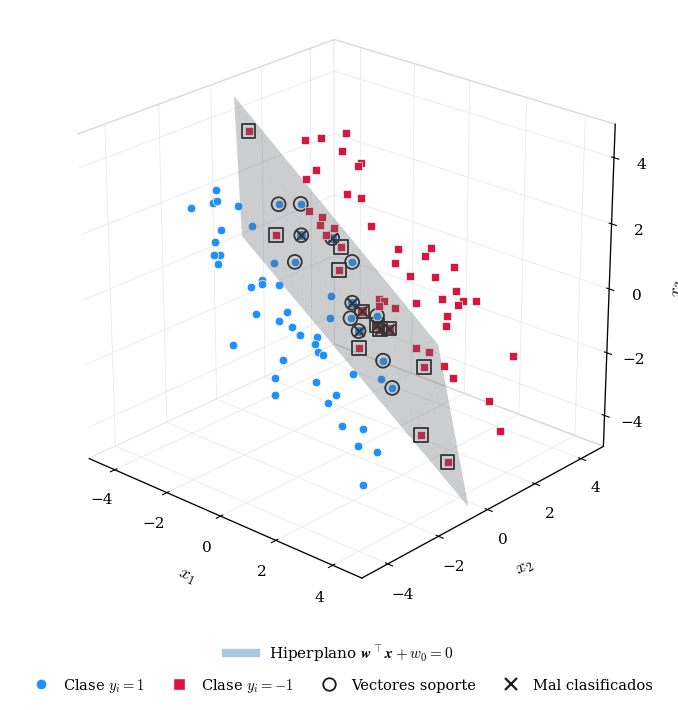

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Estilo formal / académico (mismas convenciones que las demás figuras)
# ------------------------------------------------------------------
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 11
mpl.rcParams['mathtext.fontset'] = 'cm'

rng = np.random.default_rng(42)

# -------------------------------------------------------
# Hiperplano
# -------------------------------------------------------
w = np.array([1., 1., 1.])
w = w / np.linalg.norm(w)
w0 = 0

# -------------------------------------------------------
# Base ortonormal del hiperplano (u, v dentro del plano; w es la normal)
# -------------------------------------------------------
u = np.array([1., -1., 0.])
u = u / np.linalg.norm(u)
v = np.cross(w, u)
v = v / np.linalg.norm(v)

def punto(s, t, d):
    """s, t: posición DENTRO del plano; d: distancia con signo al plano."""
    return s * u + t * v + d * w

# -------------------------------------------------------
# Datos: repartidos ampliamente en (s, t) para cubrir bien la superficie,
# y cerca del plano en d (antes los centros estaban muy lejos en la
# dirección normal, por eso se veían "flotando" lejos del hiperplano)
# -------------------------------------------------------
n = 50

s1 = rng.uniform(-4.5, 4.5, n)
t1 = rng.uniform(-4.5, 4.5, n)
d1 = rng.normal(-1.5, 0.5, n)   # antes 0.45, ahora más variado  
clase1 = np.array([punto(s, t, d) for s, t, d in zip(s1, t1, d1)])


s2 = rng.uniform(-4.5, 4.5, n)
t2 = rng.uniform(-4.5, 4.5, n)
d2 = rng.normal(1.5, 0.5, n)
clase2 = np.array([punto(s, t, d) for s, t, d in zip(s2, t2, d2)])

# -------------------------------------------------------
# Puntos mal clasificados (soft-margin: cruzan al lado contrario)
# -------------------------------------------------------
s_m1 = rng.normal(0.0, 1.2, 4)
t_m1 = rng.normal(0.0, 1.2, 4)
d_m1 = rng.uniform(0.15, 0.55, 4)   # cruzan levemente al lado positivo
mal_azules = np.array([punto(s, t, d) for s, t, d in zip(s_m1, t_m1, d_m1)])

s_m2 = rng.normal(0.0, 1.2, 4)
t_m2 = rng.normal(0.0, 1.2, 4)
d_m2 = rng.uniform(-0.55, -0.15, 4)  # cruzan levemente al lado negativo
mal_rojos = np.array([punto(s, t, d) for s, t, d in zip(s_m2, t_m2, d_m2)])

clase1 = np.vstack((clase1, mal_azules))
clase2 = np.vstack((clase2, mal_rojos))

# Índices de los puntos mal clasificados dentro de cada arreglo ya apilado
idx_mal1 = np.arange(n, n + len(mal_azules))
idx_mal2 = np.arange(n, n + len(mal_rojos))

# -------------------------------------------------------
# Vectores soporte: los más cercanos al hiperplano, PROYECTADOS
# exactamente sobre él (distancia = 0) para que se vean apoyados
# en la superficie, no flotando cerca de ella
# -------------------------------------------------------
score1 = clase1 @ w + w0
score2 = clase2 @ w + w0
dist1 = np.abs(score1)
dist2 = np.abs(score2)

n_sv = 12
idx_sv1 = np.argsort(dist1)[:n_sv]
idx_sv2 = np.argsort(dist2)[:n_sv]

for i in idx_sv1:
    clase1[i] = clase1[i] - score1[i] * w
for i in idx_sv2:
    clase2[i] = clase2[i] - score2[i] * w

# -------------------------------------------------------
# Plano parametrizado (vectorizado, sin doble for)
# -------------------------------------------------------
s = np.linspace(-5, 5, 60)
t = np.linspace(-5, 5, 60)
S, T = np.meshgrid(s, t)

P = S[:, :, None] * u + T[:, :, None] * v
XX, YY, ZZ = P[:, :, 0], P[:, :, 1], P[:, :, 2]

# ------------------------------------------------------------------
# Paleta (idéntica a las demás figuras del capítulo)
# ------------------------------------------------------------------
color_clase1 = '#1E90FF'
color_clase2 = '#DC143C'
color_sv = '#1a1a1a'

# ------------------------------------------------------------------
# Figura: plot 3D grande, leyenda compacta abajo
# ------------------------------------------------------------------
fig = plt.figure(figsize=(8.5, 8.8))  # ← Ajustado: ni tan alto (9.8) ni tan bajo (8.2)
gs = GridSpec(2, 1, height_ratios=[10, 0.9], hspace=0.12)  # ← 0.6→0.9, hspace 0.05→0.12
ax = fig.add_subplot(gs[0], projection='3d')

# Hiperplano separador (una sola superficie, sin wireframe duplicado
# encima para evitar artefactos de renderizado / z-fighting)
ax.plot_surface(XX, YY, ZZ, color="#EAF4FB", alpha=0.35,
                 edgecolor="none", shade=True, antialiased=True, zorder=1)

# Puntos regulares (excluyendo los mal clasificados, que se dibujan aparte)
mask1_ok = np.ones(len(clase1), dtype=bool)
mask1_ok[idx_mal1] = False
mask2_ok = np.ones(len(clase2), dtype=bool)
mask2_ok[idx_mal2] = False

ax.scatter(clase1[mask1_ok, 0], clase1[mask1_ok, 1], clase1[mask1_ok, 2],
           marker='o', s=38, color=color_clase1, edgecolors="white",
           linewidth=0.5, depthshade=False, zorder=3)
ax.scatter(clase2[mask2_ok, 0], clase2[mask2_ok, 1], clase2[mask2_ok, 2],
           marker='s', s=36, color=color_clase2, edgecolors="white",
           linewidth=0.5, depthshade=False, zorder=3)

# Puntos mal clasificados: mismo color de clase, borde negro para distinguirlos
# (se aplica IGUAL a ambas clases, no solo a los azules)
# Mal clasificados: mismo color de clase, con una "×" negra encima (ya no anillo)
ax.scatter(clase1[idx_mal1, 0], clase1[idx_mal1, 1], clase1[idx_mal1, 2],
           marker='o', s=50, facecolor=color_clase1, edgecolor='white',
           linewidth=0.5, depthshade=False, zorder=4)
ax.scatter(clase1[idx_mal1, 0], clase1[idx_mal1, 1], clase1[idx_mal1, 2],
           marker='x', s=55, color=color_sv, linewidth=1.6,
           depthshade=False, zorder=5)

ax.scatter(clase2[idx_mal2, 0], clase2[idx_mal2, 1], clase2[idx_mal2, 2],
           marker='s', s=46, facecolor=color_clase2, edgecolor='white',
           linewidth=0.5, depthshade=False, zorder=4)
ax.scatter(clase2[idx_mal2, 0], clase2[idx_mal2, 1], clase2[idx_mal2, 2],
           marker='x', s=55, color=color_sv, linewidth=1.6,
           depthshade=False, zorder=5)

# Vectores soporte: anillo delgado (no grueso), consistente con las demás figuras
ax.scatter(clase1[idx_sv1, 0], clase1[idx_sv1, 1], clase1[idx_sv1, 2],
           s=100, facecolors="none", edgecolors=color_sv,
           linewidth=1.3, depthshade=False, zorder=5)
ax.scatter(clase2[idx_sv2, 0], clase2[idx_sv2, 1], clase2[idx_sv2, 2],
           marker='s', s=100, facecolors="none", edgecolors=color_sv,
           linewidth=1.3, depthshade=False, zorder=5)


# ------------------------------------------------------------------
# Paneles limpios
# ------------------------------------------------------------------
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor('white')
    axis.pane.set_edgecolor('#d9d9d9')
    axis.pane.set_alpha(1.0)
    axis._axinfo['grid'].update(color='#e6e6e6', linewidth=0.5)

ax.set_xlabel(r'$x_1$', fontsize=13, labelpad=8)
ax.set_ylabel(r'$x_2$', fontsize=13, labelpad=8)
ax.set_zlabel(r'$x_3$', fontsize=13, labelpad=8)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)

ax.view_init(elev=24, azim=-48)
ax.set_box_aspect((1, 1, 0.95), zoom=1.05)



# ------------------------------------------------------------------
# Leyenda en dos niveles
# ------------------------------------------------------------------
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off')

handle_hiperplano = Line2D([0], [0], color="#A9C9E0", linewidth=6,
                            label=r'Hiperplano $\boldsymbol{w}^\top \boldsymbol{x} + w_0 = 0$')
handle_clase1 = Line2D([0], [0], marker='o', color='w', markerfacecolor=color_clase1,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i = 1$')
handle_clase2 = Line2D([0], [0], marker='s', color='w', markerfacecolor=color_clase2,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i = -1$')
handle_sv = Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                    markeredgecolor=color_sv, markeredgewidth=1.3, markersize=9,
                    label='Vectores soporte')
handle_mal = Line2D([0], [0], marker='x', color=color_sv, linestyle='None',
                     markeredgewidth=1.6, markersize=8, label='Mal clasificados')

leg1 = ax_leg.legend(handles=[handle_hiperplano],
                      loc='upper center', bbox_to_anchor=(0.5, 1.1),  # ← 0.95→1.1 (un poco arriba del panel)
                      frameon=False, fontsize=11)
ax_leg.add_artist(leg1)

ax_leg.legend(handles=[handle_clase1, handle_clase2, handle_sv, handle_mal],
              loc='upper center', bbox_to_anchor=(0.5, 0.45),  # ← 0.35→0.45 (más arriba dentro del panel)
              ncol=4, frameon=False, fontsize=10.5,
              handletextpad=0.5, columnspacing=1.4)



plt.show()

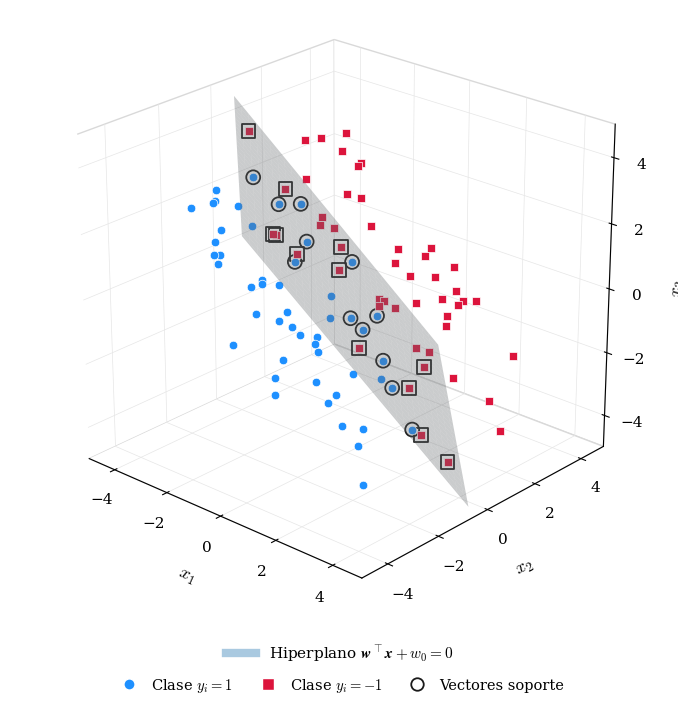

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Estilo formal / académico (mismas convenciones que las demás figuras)
# ------------------------------------------------------------------
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 11
mpl.rcParams['mathtext.fontset'] = 'cm'

rng = np.random.default_rng(42)

# -------------------------------------------------------
# Hiperplano
# -------------------------------------------------------
w = np.array([1., 1., 1.])
w = w / np.linalg.norm(w)
w0 = 0

# -------------------------------------------------------
# Base ortonormal del hiperplano (u, v dentro del plano; w es la normal)
# -------------------------------------------------------
u = np.array([1., -1., 0.])
u = u / np.linalg.norm(u)
v = np.cross(w, u)
v = v / np.linalg.norm(v)

def punto(s, t, d):
    """s, t: posición DENTRO del plano; d: distancia con signo al plano."""
    return s * u + t * v + d * w

# -------------------------------------------------------
# Datos: repartidos ampliamente en (s, t) para cubrir bien la superficie,
# y cerca del plano en d (antes los centros estaban muy lejos en la
# dirección normal, por eso se veían "flotando" lejos del hiperplano)
# -------------------------------------------------------
n = 50

s1 = rng.uniform(-4.5, 4.5, n)
t1 = rng.uniform(-4.5, 4.5, n)
d1 = rng.normal(-1.5, 0.5, n)   # antes 0.45, ahora más variado  
clase1 = np.array([punto(s, t, d) for s, t, d in zip(s1, t1, d1)])


s2 = rng.uniform(-4.5, 4.5, n)
t2 = rng.uniform(-4.5, 4.5, n)
d2 = rng.normal(1.5, 0.5, n)
clase2 = np.array([punto(s, t, d) for s, t, d in zip(s2, t2, d2)])

# -------------------------------------------------------
# Vectores soporte: los más cercanos al hiperplano, PROYECTADOS
# exactamente sobre él (distancia = 0) para que se vean apoyados
# en la superficie, no flotando cerca de ella
# -------------------------------------------------------
score1 = clase1 @ w + w0
score2 = clase2 @ w + w0
dist1 = np.abs(score1)
dist2 = np.abs(score2)

n_sv = 12
idx_sv1 = np.argsort(dist1)[:n_sv]
idx_sv2 = np.argsort(dist2)[:n_sv]

for i in idx_sv1:
    clase1[i] = clase1[i] - score1[i] * w
for i in idx_sv2:
    clase2[i] = clase2[i] - score2[i] * w

# -------------------------------------------------------
# Plano parametrizado (vectorizado, sin doble for)
# -------------------------------------------------------
s = np.linspace(-5, 5, 60)
t = np.linspace(-5, 5, 60)
S, T = np.meshgrid(s, t)

P = S[:, :, None] * u + T[:, :, None] * v
XX, YY, ZZ = P[:, :, 0], P[:, :, 1], P[:, :, 2]

# ------------------------------------------------------------------
# Paleta (idéntica a las demás figuras del capítulo)
# ------------------------------------------------------------------
color_clase1 = '#1E90FF'
color_clase2 = '#DC143C'
color_sv = '#1a1a1a'

# ------------------------------------------------------------------
# Figura: plot 3D grande, leyenda compacta abajo
# ------------------------------------------------------------------
fig = plt.figure(figsize=(8.5, 8.8))  # ← Ajustado: ni tan alto (9.8) ni tan bajo (8.2)
gs = GridSpec(2, 1, height_ratios=[10, 0.9], hspace=0.12)  # ← 0.6→0.9, hspace 0.05→0.12
ax = fig.add_subplot(gs[0], projection='3d')

# Hiperplano separador (una sola superficie, sin wireframe duplicado
# encima para evitar artefactos de renderizado / z-fighting)
ax.plot_surface(XX, YY, ZZ, color="#EAF4FB", alpha=0.35,
                 edgecolor="none", shade=True, antialiased=True, zorder=1)

# Puntos de ambas clases
ax.scatter(clase1[:, 0], clase1[:, 1], clase1[:, 2],
           marker='o', s=38, color=color_clase1, edgecolors="white",
           linewidth=0.5, depthshade=False, zorder=3)
ax.scatter(clase2[:, 0], clase2[:, 1], clase2[:, 2],
           marker='s', s=36, color=color_clase2, edgecolors="white",
           linewidth=0.5, depthshade=False, zorder=3)

# Vectores soporte: anillo delgado (no grueso), consistente con las demás figuras
ax.scatter(clase1[idx_sv1, 0], clase1[idx_sv1, 1], clase1[idx_sv1, 2],
           s=100, facecolors="none", edgecolors=color_sv,
           linewidth=1.3, depthshade=False, zorder=5)
ax.scatter(clase2[idx_sv2, 0], clase2[idx_sv2, 1], clase2[idx_sv2, 2],
           marker='s', s=100, facecolors="none", edgecolors=color_sv,
           linewidth=1.3, depthshade=False, zorder=5)


# ------------------------------------------------------------------
# Paneles limpios
# ------------------------------------------------------------------
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor('white')
    axis.pane.set_edgecolor('#d9d9d9')
    axis.pane.set_alpha(1.0)
    axis._axinfo['grid'].update(color='#e6e6e6', linewidth=0.5)

ax.set_xlabel(r'$x_1$', fontsize=13, labelpad=8)
ax.set_ylabel(r'$x_2$', fontsize=13, labelpad=8)
ax.set_zlabel(r'$x_3$', fontsize=13, labelpad=8)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)

ax.view_init(elev=24, azim=-48)
ax.set_box_aspect((1, 1, 0.95), zoom=1.05)



# ------------------------------------------------------------------
# Leyenda en dos niveles
# ------------------------------------------------------------------
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off')

handle_hiperplano = Line2D([0], [0], color="#A9C9E0", linewidth=6,
                            label=r'Hiperplano $\boldsymbol{w}^\top \boldsymbol{x} + w_0 = 0$')
handle_clase1 = Line2D([0], [0], marker='o', color='w', markerfacecolor=color_clase1,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i = 1$')
handle_clase2 = Line2D([0], [0], marker='s', color='w', markerfacecolor=color_clase2,
                        markersize=8, markeredgecolor='white', label=r'Clase $y_i = -1$')
handle_sv = Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                    markeredgecolor=color_sv, markeredgewidth=1.3, markersize=9,
                    label='Vectores soporte')

leg1 = ax_leg.legend(handles=[handle_hiperplano],
                      loc='upper center', bbox_to_anchor=(0.5, 1.1),  # ← 0.95→1.1 (un poco arriba del panel)
                      frameon=False, fontsize=11)
ax_leg.add_artist(leg1)

ax_leg.legend(handles=[handle_clase1, handle_clase2, handle_sv],
              loc='upper center', bbox_to_anchor=(0.5, 0.45),  # ← 0.35→0.45 (más arriba dentro del panel)
              ncol=3, frameon=False, fontsize=10.5,
              handletextpad=0.5, columnspacing=1.4)



plt.show()

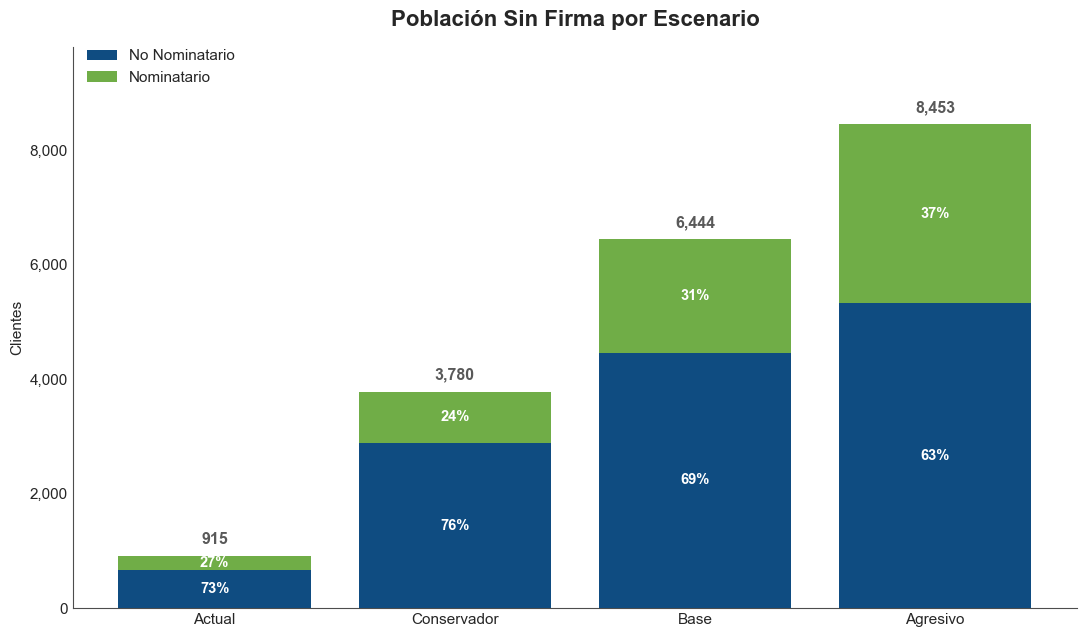

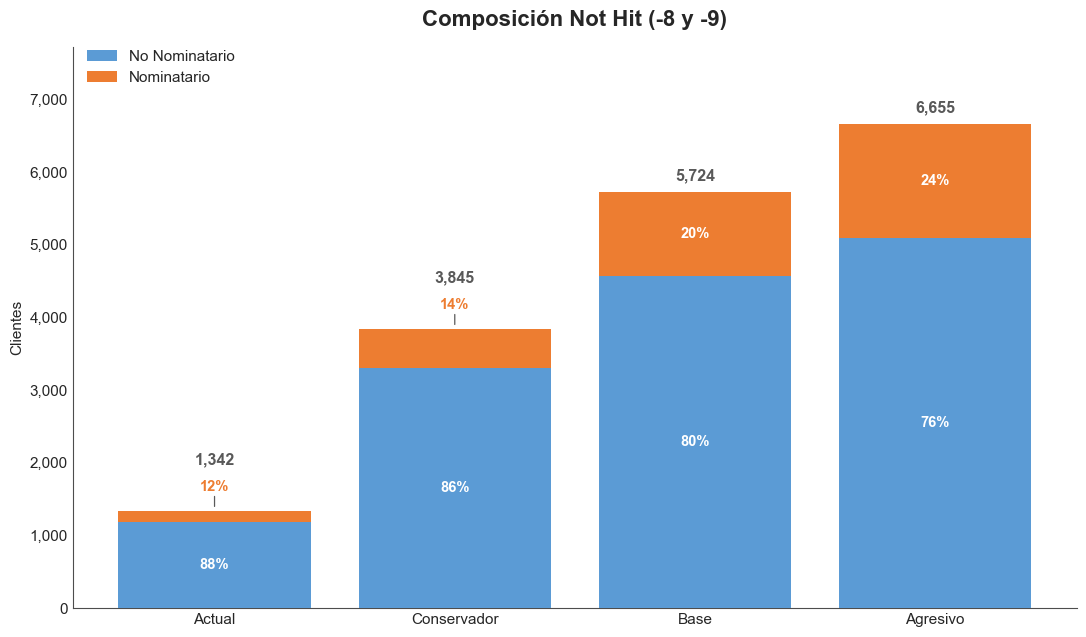

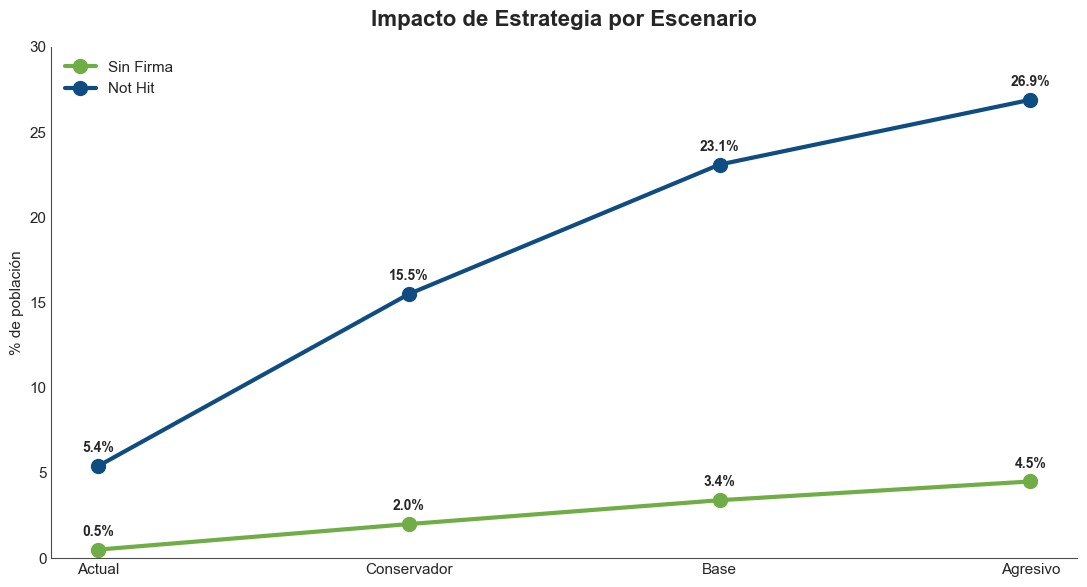

In [99]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# =========================================================
# Datos
# =========================================================

ESCENARIOS = ['Actual', 'Conservador', 'Base', 'Agresivo']

# --- Sin Firma: composición por tipo de cliente ---
SF_NO_NOM = [668, 2884, 4462, 5324]     # Sin firma / No nominatario
SF_NOM    = [247,  896, 1982, 3129]     # Sin firma / Nominatario

# --- Not Hit (-8 y -9): composición por tipo de cliente ---
NH_NO_NOM = [1182, 3306, 4571, 5091]    # Not hit / No nominatario
NH_NOM    = [ 160,  539, 1153, 1564]    # Not hit / Nominatario

# --- % de población total (para la gráfica de impacto) ---
PCT_SIN_FIRMA = [0.5, 2.0, 3.4, 4.5]
PCT_NOT_HIT   = [5.4, 15.5, 23.1, 26.9]

# =========================================================
# Estilo ejecutivo
# =========================================================

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.edgecolor': '#4d4d4d',
    'axes.linewidth': 0.8,
    'axes.grid': False,          # quitamos grid, más limpio para presentar
})

COLORS = {
    'azul':        '#0F4C81',
    'azul_claro':  '#5B9BD5',
    'verde':       '#70AD47',
    'naranja':     '#ED7D31',
    'gris':        '#595959',
}


def formatea_miles(x, pos):
    return f'{x:,.0f}'


def grafica_composicion(no_nom, nom, color_no_nom, color_nom, titulo, archivo=None,
                         umbral_callout=0.15):
    """
    Barra apilada No Nominatario / Nominatario, con:
      - etiqueta de total arriba de cada barra
      - % de No Nominatario dentro de su segmento (siempre, es el mayoritario)
      - % de Nominatario dentro de su segmento si hay espacio; si el segmento
        es muy delgado (< umbral_callout), la etiqueta se saca de la barra
        con una línea guía (callout) hacia arriba, para que nunca quede
        ilegible ni escondida
    """
    no_nom = np.array(no_nom)
    nom = np.array(nom)
    totales = no_nom + nom
    pct_no_nom = no_nom / totales * 100
    pct_nom = nom / totales * 100

    fig, ax = plt.subplots(figsize=(11, 6.5))

    ax.bar(ESCENARIOS, no_nom, color=color_no_nom, label='No Nominatario', zorder=3)
    ax.bar(ESCENARIOS, nom, bottom=no_nom, color=color_nom, label='Nominatario', zorder=3)

    y_max = totales.max()

    for i in range(len(ESCENARIOS)):
        # --- No Nominatario: siempre dentro del segmento (es el mayoritario) ---
        ax.text(i, no_nom[i] / 2, f'{pct_no_nom[i]:.0f}%',
                ha='center', va='center', color='white', fontsize=10.5,
                fontweight='bold', zorder=4)

        # --- Nominatario: dentro si cabe, callout arriba si el segmento es delgado ---
        segmento_frac = nom[i] / totales[i]
        punto_medio_segmento = no_nom[i] + nom[i] / 2

        if segmento_frac >= umbral_callout:
            ax.text(i, punto_medio_segmento, f'{pct_nom[i]:.0f}%',
                    ha='center', va='center', color='white', fontsize=10.5,
                    fontweight='bold', zorder=4)
            # Total pegado arriba de la barra, como en el caso normal
            ax.text(i, totales[i] + y_max * 0.025, f'{totales[i]:,.0f}',
                    ha='center', fontsize=11.5, fontweight='bold', color=COLORS['gris'], zorder=4)
        else:
            # Callout pegado justo arriba de la barra (línea guía corta)
            y_callout = totales[i] + y_max * 0.035
            ax.annotate(
                f'{pct_nom[i]:.0f}%',
                xy=(i, no_nom[i] + nom[i]),
                xytext=(i, y_callout),
                ha='center', va='bottom',
                fontsize=10.5, fontweight='bold', color=color_nom,
                arrowprops=dict(arrowstyle='-', color=COLORS['gris'], lw=0.9,
                                shrinkA=0, shrinkB=3),
                zorder=5,
            )
            # Total arriba del callout (no al revés)
            ax.text(i, y_callout + y_max * 0.06, f'{totales[i]:,.0f}',
                    ha='center', fontsize=11.5, fontweight='bold', color=COLORS['gris'], zorder=4)

    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Clientes')
    ax.set_ylim(0, y_max * 1.16)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 1.02))
    ax.yaxis.set_major_formatter(FuncFormatter(formatea_miles))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if archivo:
        plt.savefig(archivo, dpi=150, bbox_inches='tight')
    plt.show()


def grafica_impacto(pct_sin_firma, pct_not_hit, archivo=None):
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.plot(ESCENARIOS, pct_sin_firma, marker='o', markersize=10, linewidth=3,
            color=COLORS['verde'], label='Sin Firma')
    ax.plot(ESCENARIOS, pct_not_hit, marker='o', markersize=10, linewidth=3,
            color=COLORS['azul'], label='Not Hit')

    for x, y in zip(ESCENARIOS, pct_sin_firma):
        ax.annotate(f'{y:.1f}%', (x, y), xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')

    for x, y in zip(ESCENARIOS, pct_not_hit):
        ax.annotate(f'{y:.1f}%', (x, y), xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')

    ax.set_title('Impacto de Estrategia por Escenario', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('% de población')
    ax.set_ylim(0, 30)
    ax.legend(frameon=False, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    if archivo:
        plt.savefig(archivo, dpi=150, bbox_inches='tight')
    plt.show()


# =========================================================
# Generación de las 3 gráficas
# =========================================================

grafica_composicion(
    SF_NO_NOM, SF_NOM,
    color_no_nom=COLORS['azul'], color_nom=COLORS['verde'],
    titulo='Población Sin Firma por Escenario',
    archivo='sin_firma.png',
)

grafica_composicion(
    NH_NO_NOM, NH_NOM,
    color_no_nom=COLORS['azul_claro'], color_nom=COLORS['naranja'],
    titulo='Composición Not Hit (-8 y -9)',
    archivo='not_hit.png',
)

grafica_impacto(PCT_SIN_FIRMA, PCT_NOT_HIT, archivo='impacto.png')